<h1 style="text-align: center;">Part I — Provided Geometric Analysis</h1>

> **Provided code — no modifications required**
>
> The following cells perform the geometric analysis of the four-bar linkage.
> Run these cells before beginning the assignment. You are **not required to modify or complete** the code in this section.
>
> The results generated here will be used as inputs for the subsequent velocity, acceleration, force, and stress analyses.

# 4-Bar Linkage Analysis

Consider the following 4-bar linkage. This mechanism will be used in the upcoming analysis.

<div style="text-align: center;">
    <img src="4-bar linkage GA1.PNG" width="500">
</div>

## Imports

In [2]:
import numpy as np
import matplotlib.pyplot as plt

## Parameters

The lengths of the links, measured in mm, are provided.

In [3]:
# Link lengths (meters)
L0 = 0.350   # Ground link
L1 = 0.250   # Crank
L2 = 0.400   # Coupler
L3 = 0.330   # Follower

In [4]:
# Grashof Contraint?
Arr_v = sorted([L0,L1,L2,L3])
print(Arr_v)
if (Arr_v[0] + Arr_v[3])<(Arr_v[1] + Arr_v[2]):
    print('Grashof')
else:
    print('Not Grashof')

[0.25, 0.33, 0.35, 0.4]
Grashof


## Input

In [5]:
# Array of values for theta1 from 0 to 2*pi
theta1_array = np.linspace(0, 2*np.pi, 500)

## Fixed Points

In [6]:
# Fixed joints
A = np.array([0.0, 0.0])
D = np.array([L0, 0.0])

## Methods

In [8]:
def fourbar_position(theta1, L0, L1, L2, L3, A, D):

    # Crank endpoint
    B = np.array([
        L1*np.cos(theta1),
        L1*np.sin(theta1)
    ])

    # Distance between circle centers
    dx = D[0] - B[0]
    dy = D[1] - B[1]

    d = np.sqrt(dx**2 + dy**2)

    a = (L2**2 - L3**2 + d**2) / (2*d) # a: Distance from B to intersection P, P: See Line 28

    h = np.sqrt(L2**2 - a**2) # d: Distance from P to intersections C1 and C2

    P = B + (a/d)*(D-B) # P: Intersetion of line connecting circle centers B and D, and the line connecting the intersections C1 and C2

    perp = np.array([-dy/d, dx/d]) # Computes a unit vertor perpendicular to segment BD

    # Two possible configurations
    C1 = P + h*perp
    C2 = P - h*perp

    return B, C1, C2

# Geometric Analysis

In [10]:
# ============================================================
# GEOMETRIC ANALYSIS
# ============================================================
# For each input angle theta1, this section determines:
#   theta2: coupler angle
#   theta3: follower angle
#   G:      center of mass of the coupler
#
# The resulting scalar quantities are stored as one-dimensional
# NumPy arrays with shape (N,), where N is the number of
# successfully evaluated mechanism configurations.
# ============================================================

# Input angular positions
theta1_values = np.linspace(0, 2*np.pi, 500)

# Initialize lists for storing the results
theta1_results = []
theta2_results = []
theta3_results = []

Gx = []
Gy = []

# Position of the fixed joint D
D = np.array([L0, 0.0])


# Evaluate the mechanism for each input angle theta1
for theta1 in theta1_values:

    # Determine the position of the moving joints
    result = fourbar_position(theta1, L0, L1, L2, L3, A, D)

    # Skip configurations that cannot be reached by the mechanism
    if result is None:
        continue

    B, C1, C2 = result

    # Choose assembly mode (C1 or C2)
    C = C2

    # Calculate the angular position of the coupler
    theta2 = np.arctan2(
        C[1] - B[1],
        C[0] - B[0]
    )

    # Calculate the angular position of the follower
    theta3 = np.arctan2(
        C[1] - D[1],
        C[0] - D[0]
    )

    # Calculate the center of mass of the coupler
    # (assuming its center of mass is located at its midpoint)
    G = (B + C)/2

    # Store the results
    theta1_results.append(theta1)
    theta2_results.append(theta2)
    theta3_results.append(theta3)

    Gx.append(G[0])
    Gy.append(G[1])


# ============================================================
# CONVERT RESULTS TO NUMPY ARRAYS
# ============================================================
# Each variable below is a one-dimensional array with shape (N,).
# Element i of each array corresponds to the same mechanism
# configuration.

theta1_results = np.array(theta1_results)
theta2_results = np.array(theta2_results)
theta3_results = np.array(theta3_results)

Gx = np.array(Gx)
Gy = np.array(Gy)

# Remove ±180° discontinuities from the angular positions
theta2_results = np.unwrap(theta2_results)
theta3_results = np.unwrap(theta3_results)

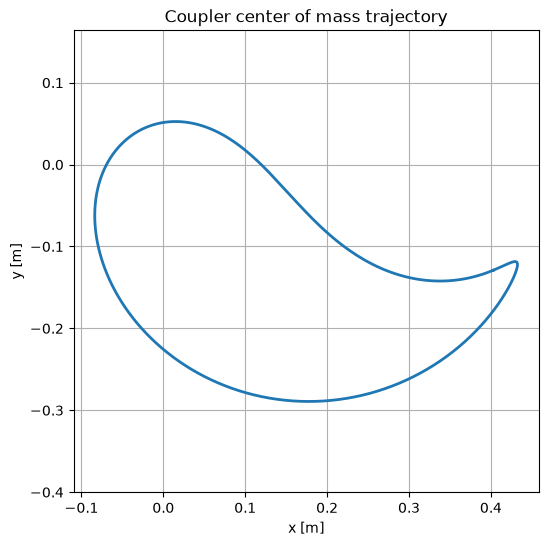

In [11]:
# ============================================================
# PLOT: COUPLER CENTER OF MASS TRAJECTORY
# ============================================================

plt.figure(figsize=(6,6))

plt.plot(Gx, Gy, linewidth=2)

plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("Coupler center of mass trajectory")

plt.axis("equal")
plt.grid(True)

plt.show()


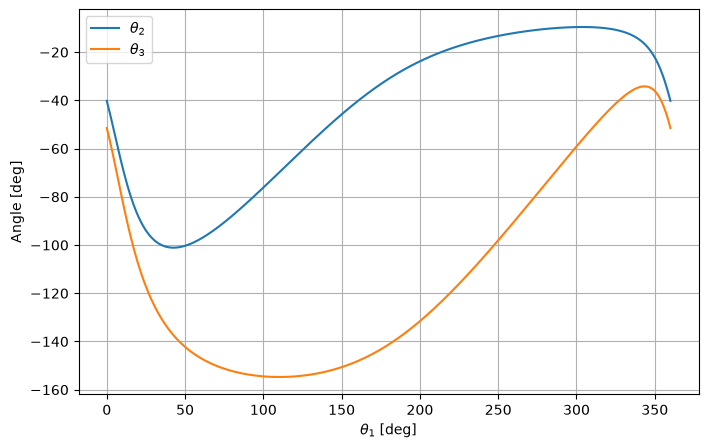

In [12]:
# ============================================================
# PLOT: ANGULAR POSITIONS
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(
    np.rad2deg(theta1_results),
    np.rad2deg(theta2_results),
    label=r"$\theta_2$"
)

plt.plot(
    np.rad2deg(theta1_results),
    np.rad2deg(theta3_results),
    label=r"$\theta_3$"
)

plt.xlabel(r"$\theta_1$ [deg]")
plt.ylabel("Angle [deg]")

plt.grid(True)
plt.legend()

plt.show()

---

<h1 style="text-align: center;">Part II — Student Work</h1>

> **Your work begins here.**
>
> Complete the following sections using the results generated by the geometric analysis:
>
> 1. Velocity Analysis
> 2. Acceleration Analysis
> 3. Force Analysis
> 4. Stress Analysis

# Velocity Analysis

In the following cell, perform the velocity analysis of the four-bar linkage.

Let $N$ denote the number of mechanism configurations obtained from the geometric analysis. In this case, $N = 500$.

**The available inputs are:**

1. The angular velocity of Link 1, which is constant and equal to $\omega_1 = 2$ rad/s (scalar).  

2. The angular positions obtained from the geometric analysis:
   - *theta1_results* ($\theta_1$): shape $(N,)$
   - *theta2_results* ($\theta_2$): shape $(N,)$
   - *theta3_results* ($\theta_3$): shape $(N,)$

**The expected outputs are:**

1. The angular velocity of Link 2, $\omega_2$, for each mechanism configuration.  
   **Shape:** $(N,)$

2. The angular velocity of Link 3, $\omega_3$, for each mechanism configuration.  
   **Shape:** $(N,)$

3. The magnitude of the velocity of the center of mass of the coupler (Link 2), $|v_G|$, for each mechanism configuration.  
   **Shape:** $(N,)$


**Plot the following results as functions of $\theta_1$:**

1. $\omega_2$ and $\omega_3$ in the same figure, in rad/s.
2. $|v_G|$ in a separate figure, in m/s.

Use $\theta_1$ in degrees for the horizontal axis. Include appropriate axis labels, legends, titles, and grid lines.


<div style="text-align: center;">
    <img src="4-bar linkage VA.PNG" width="500">
</div>
   

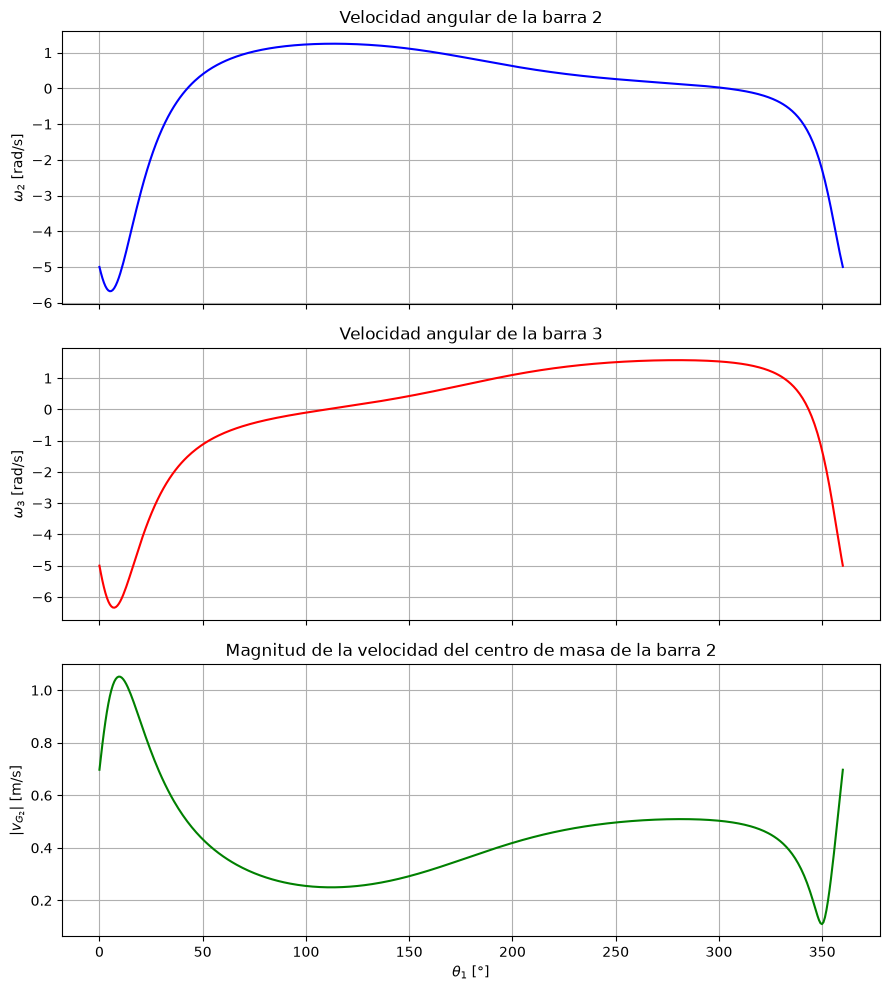

In [27]:
# Angular velocity of Link 1
omega1 = 2.0  # rad/s

# Number of mechanism configurations
N = len(theta1_results)

# Initialize arrays for storing results
omega2_results = np.zeros(N)
omega3_results = np.zeros(N)
vG_magnitude_results = np.zeros(N)

# Perform velocity analysis for each mechanism configuration
for i in range(N):

    theta1 = theta1_results[i]
    theta2 = theta2_results[i]
    theta3 = theta3_results[i]

    # ---------------------------------------------------------
    # Complete the velocity analysis here
    # ---------------------------------------------------------

#Escribo la velocidad en terminos matriciales con el fin de despejar facilemente

#Matriz de coeficientes
    A = np.array([
    
        [L2*np.sin(theta2), -L3*np.sin(theta3)],
        [-L2*np.cos(theta2), L3*np.cos(theta3)]
           
    ])

#vector al cual se iguala la matriz de coeficientes

    b = np.array([
        
        -L1*omega1*np.sin(theta1),
         L1*omega1*np.cos(theta1)
        
    ])

    w2, w3 = np.linalg.solve(A, b)


    omega2_results[i] = w2
    
    omega3_results[i] = w3

#Ahora, para la magnitud de la velocidad en el centro de masa

    V_COMX = (-L2/2)*w2*np.sin(theta2) - L1*omega1*np.sin(theta1) 
    V_COMY = (L2/2)*w2*np.cos(theta2) + L1*omega1*np.cos(theta1)

    vel_COM = np.sqrt((V_COMX**2) + (V_COMY**2)) 
    
    vG_magnitude_results[i] = vel_COM


#Graficacion

theta1_deg = np.rad2deg(theta1_results)

fig, axes = plt.subplots(3, 1, figsize=(9, 10), sharex=True)

axes[0].plot(theta1_deg, omega2_results, color="blue")
axes[0].set_ylabel(r"$\omega_2$ [rad/s]")
axes[0].set_title("Velocidad angular de la barra 2")
axes[0].grid(True)

axes[1].plot(theta1_deg, omega3_results, color="red")
axes[1].set_ylabel(r"$\omega_3$ [rad/s]")
axes[1].set_title("Velocidad angular de la barra 3")
axes[1].grid(True)

axes[2].plot(theta1_deg, vG_magnitude_results, color="green")
axes[2].set_ylabel(r"$|v_{G_2}|$ [m/s]")
axes[2].set_xlabel(r"$\theta_1$ [°]")
axes[2].set_title("Magnitud de la velocidad del centro de masa de la barra 2")
axes[2].grid(True)

plt.tight_layout()
plt.show()

    




# Acceleration Analysis

In the following cell, perform the acceleration analysis of the four-bar linkage.

Let $N$ denote the number of mechanism configurations obtained from the geometric analysis. In this case, $N = 500$.

**The available inputs are:**

1. The angular velocity of Link 1, which is constant and equal to $\omega_1 = 2$ rad/s. Therefore, its angular acceleration is $\alpha_1 = 0$ rad/s².  
   **Shape:** scalar

2. The angular positions obtained from the geometric analysis:
   - *theta1_results* ($\theta_1$): shape $(N,)$
   - *theta2_results* ($\theta_2$): shape $(N,)$
   - *theta3_results* ($\theta_3$): shape $(N,)$

3. The angular velocities obtained from the velocity analysis:
   - *omega2_results* ($\omega_2$): shape $(N,)$
   - *omega3_results* ($\omega_3$): shape $(N,)$

**The expected outputs are:**

1. The angular acceleration of Link 2, $\alpha_2$, for each mechanism configuration.  
   **Shape:** $(N,)$

2. The angular acceleration of Link 3, $\alpha_3$, for each mechanism configuration.  
   **Shape:** $(N,)$

3. The magnitude of the acceleration of the center of mass of the coupler (Link 2), $|a_G|$, for each mechanism configuration.  
   **Shape:** $(N,)$

4. The acceleration vector of the center of mass of Link 2, $\vec{a}_{G_2}$, for each mechanism configuration.  
   **Shape:** $(N,2)$

5. The acceleration vector of the center of mass of Link 3, $\vec{a}_{G_3}$, for each mechanism configuration.  
   **Shape:** $(N,2)$

6. The magnitude of the acceleration of the center of mass of Link 2, $|\vec{a}_{G_2}|$, for each mechanism configuration.  
   **Shape:** $(N,)$

**Plot the following results as functions of $\theta_1$:**

1. $\alpha_2$ and $\alpha_3$ in the same figure, in rad/s².
2. $|a_G|$ in a separate figure, in m/s².

Use $\theta_1$ in degrees for the horizontal axis. Include appropriate axis labels, legends, titles, and grid lines.


<div style="text-align: center;">
    <img src="4-bar linkage AA.PNG" width="500">
</div>

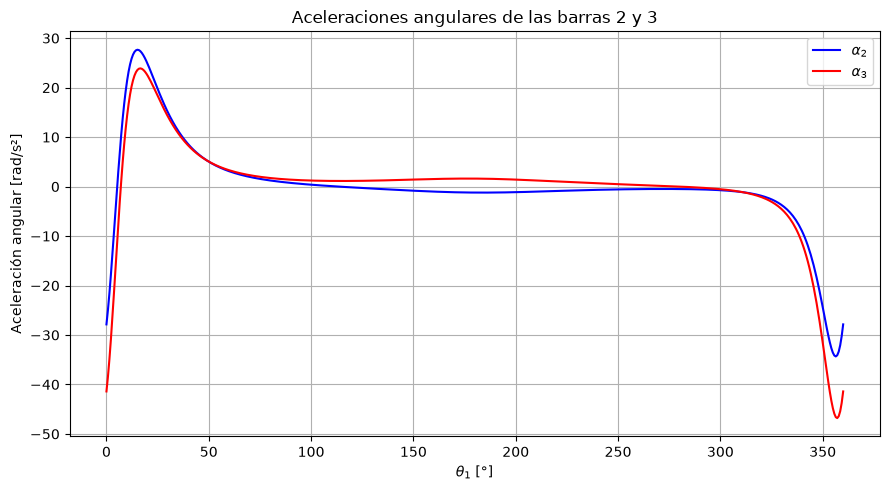

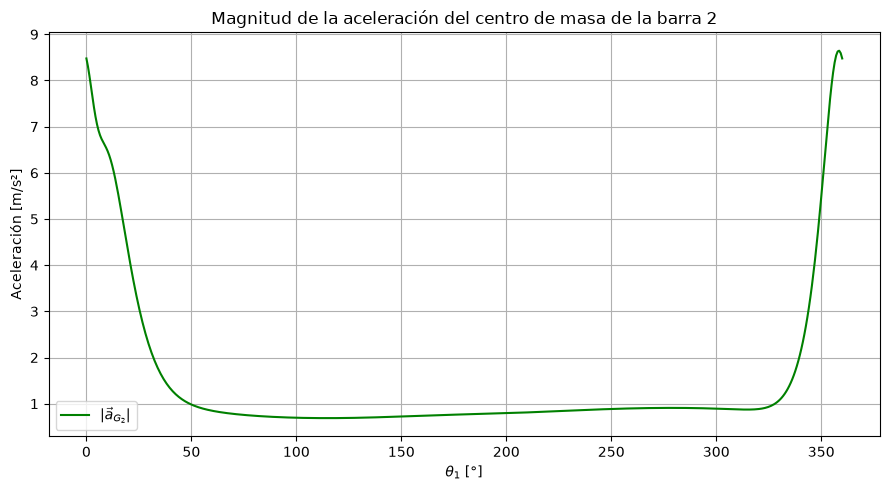

In [29]:
# Angular acceleration of Link 1
alpha1 = 0.0  # rad/s^2

# Number of mechanism configurations
N = len(theta1_results)

# Initialize arrays for storing angular accelerations
alpha2_results = np.zeros(N)
alpha3_results = np.zeros(N)

# Initialize arrays for storing COM acceleration vectors
# Each row contains [ax, ay] for one mechanism configuration
aG1_results = np.zeros((N, 2))
aG2_results = np.zeros((N, 2))
aG3_results = np.zeros((N, 2))

# Magnitude of the acceleration of the COM of Link 2
aG2_magnitude_results = np.zeros(N)


# Perform acceleration analysis for each mechanism configuration
for i in range(N):

    theta1 = theta1_results[i]
    theta2 = theta2_results[i]
    theta3 = theta3_results[i]

    omega2 = omega2_results[i]
    omega3 = omega3_results[i]

    # ---------------------------------------------------------
    # Complete the acceleration analysis here
    #
    # 1. Determine alpha2 and alpha3.
    # 2. Calculate the acceleration of the center of mass
    #    of Links 1, 2, and 3.
    # 3. Store the corresponding results.
    # 4. Calculate and store the magnitude of aG2.b
    # ---------------------------------------------------------
#Matriz de coeficientes

    A = np.array([

        [L2*np.sin(theta2), -L3*np.sin(theta3)],
        [-L2*np.cos(theta2), L3*np.cos(theta3)]
        
    ])

    b = np.array([

        -L1*(omega1**2)*np.cos(theta1) - L2*(omega2**2)*np.cos(theta2) + L3*(omega3**2)*np.cos(theta3),
        
        -L1*(omega1**2)*np.sin(theta1) - L2*(omega2**2)*np.sin(theta2) + L3*(omega3**2)*np.sin(theta3)
        
    ])

    al2, al3 = np.linalg.solve(A, b)

    alpha2_results[i] = al2

    alpha3_results[i] = al3

#Aceleracion de los centros de masa

    aG1_results[i] = [
        -(L1/2)*alpha1*np.sin(theta1) - (L1/2)*omega1**2*np.cos(theta1),

        (L1/2)*alpha1*np.cos(theta1) - (L1/2)*omega1**2*np.sin(theta1)
    ]

    a_BX = -L1*alpha1*np.sin(theta1) - L1*omega1**2*np.cos(theta1)
    a_BY =  L1*alpha1*np.cos(theta1) - L1*omega1**2*np.sin(theta1)
    

    aG2_results[i] = [
        a_BX - (L2/2)*al2*np.sin(theta2) - (L2/2)*omega2**2*np.cos(theta2),

        a_BY + (L2/2)*al2*np.cos(theta2) - (L2/2)*omega2**2*np.sin(theta2)
    ]
    

    aG3_results[i] = [
        -(L3/2)*al3*np.sin(theta3) - (L3/2)*omega3**2*np.cos(theta3),

        (L3/2)*al3*np.cos(theta3) - (L3/2)*omega3**2*np.sin(theta3)
    ]

    aG2_magnitude_results[i] = np.linalg.norm(aG2_results[i])

    


# -------------------------------------------------------------
# Plot the requested results as functions of theta1
# -------------------------------------------------------------

theta1_deg = np.rad2deg(theta1_results)

plt.figure(figsize=(9, 5))
plt.plot(theta1_deg, alpha2_results, label=r"$\alpha_2$", color="blue")
plt.plot(theta1_deg, alpha3_results, label=r"$\alpha_3$", color="red")
plt.xlabel(r"$\theta_1$ [°]")
plt.ylabel("Aceleración angular [rad/s²]")
plt.title("Aceleraciones angulares de las barras 2 y 3")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(theta1_deg, aG2_magnitude_results,
         label=r"$|\vec{a}_{G_2}|$", color="green")
plt.xlabel(r"$\theta_1$ [°]")
plt.ylabel("Aceleración [m/s²]")
plt.title("Magnitud de la aceleración del centro de masa de la barra 2")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Force Analysis

In the following cell, perform the dynamic force analysis of the four-bar linkage using the results obtained from the position, velocity, and acceleration analyses.

For each mechanism configuration, apply the Newton-Euler equations to Links 1, 2, and 3.

Let $N$ denote the number of mechanism configurations. In this case, $N = 500$.

**The available inputs are:**

1. The angular positions of the three moving links:
   - *theta1_results* ($\theta_1$): shape $(N,)$
   - *theta2_results* ($\theta_2$): shape $(N,)$
   - *theta3_results* ($\theta_3$): shape $(N,)$

2. The angular accelerations:
   - $\alpha_1 = 0$ rad/s²
   - *alpha2_results* ($\alpha_2$): shape $(N,)$
   - *alpha3_results* ($\alpha_3$): shape $(N,)$

3. The acceleration vectors of the centers of mass:
   - *aG1_results* ($\vec{a}_{G_1}$): shape $(N,2)$
   - *aG2_results* ($\vec{a}_{G_2}$): shape $(N,2)$
   - *aG3_results* ($\vec{a}_{G_3}$): shape $(N,2)$

4. The masses of the moving links:
   - Link 1: $m_1 = 0.80$ kg
   - Link 2: $m_2 = 1.05$ kg
   - Link 3: $m_3 = 0.85$ kg

5. The mass moments of inertia about the center of mass of each link:
   - Link 1: $I_{G_1} = 5.10\times10^{-3}$ kg·m²
   - Link 2: $I_{G_2} = 1.24\times10^{-2}$ kg·m²
   - Link 3: $I_{G_3} = 6.40\times10^{-3}$ kg·m²

6. The gravitational acceleration:
   - $g = 9.81$ m/s²

Assume that the joints are ideal and frictionless. The centers of mass of the links are located at their respective geometric centers.


Assume that the joints are ideal and frictionless.

**The expected outputs are:**

1. The reaction force at joint $A$:
   - $A_x$: shape $(N,)$
   - $A_y$: shape $(N,)$

2. The reaction force at joint $B$:
   - $B_x$: shape $(N,)$
   - $B_y$: shape $(N,)$

3. The reaction force at joint $C$:
   - $C_x$: shape $(N,)$
   - $C_y$: shape $(N,)$

4. The reaction force at joint $D$:
   - $D_x$: shape $(N,)$
   - $D_y$: shape $(N,)$

5. The input torque required at Link 1, $T_1$, for each mechanism configuration.  
   **Shape:** $(N,)$

**Plot the following results as functions of $\theta_1$:**

1. The $x$- and $y$-components of the reaction force at joint $A$.
2. The $x$- and $y$-components of the reaction force at joint $B$.
3. The $x$- and $y$-components of the reaction force at joint $C$.
4. The $x$- and $y$-components of the reaction force at joint $D$.
5. The required input torque $T_1$.

Use $\theta_1$ in degrees for the horizontal axis. Forces must be expressed in N and torque in N·m. Include appropriate axis labels, legends, titles, and grid lines.

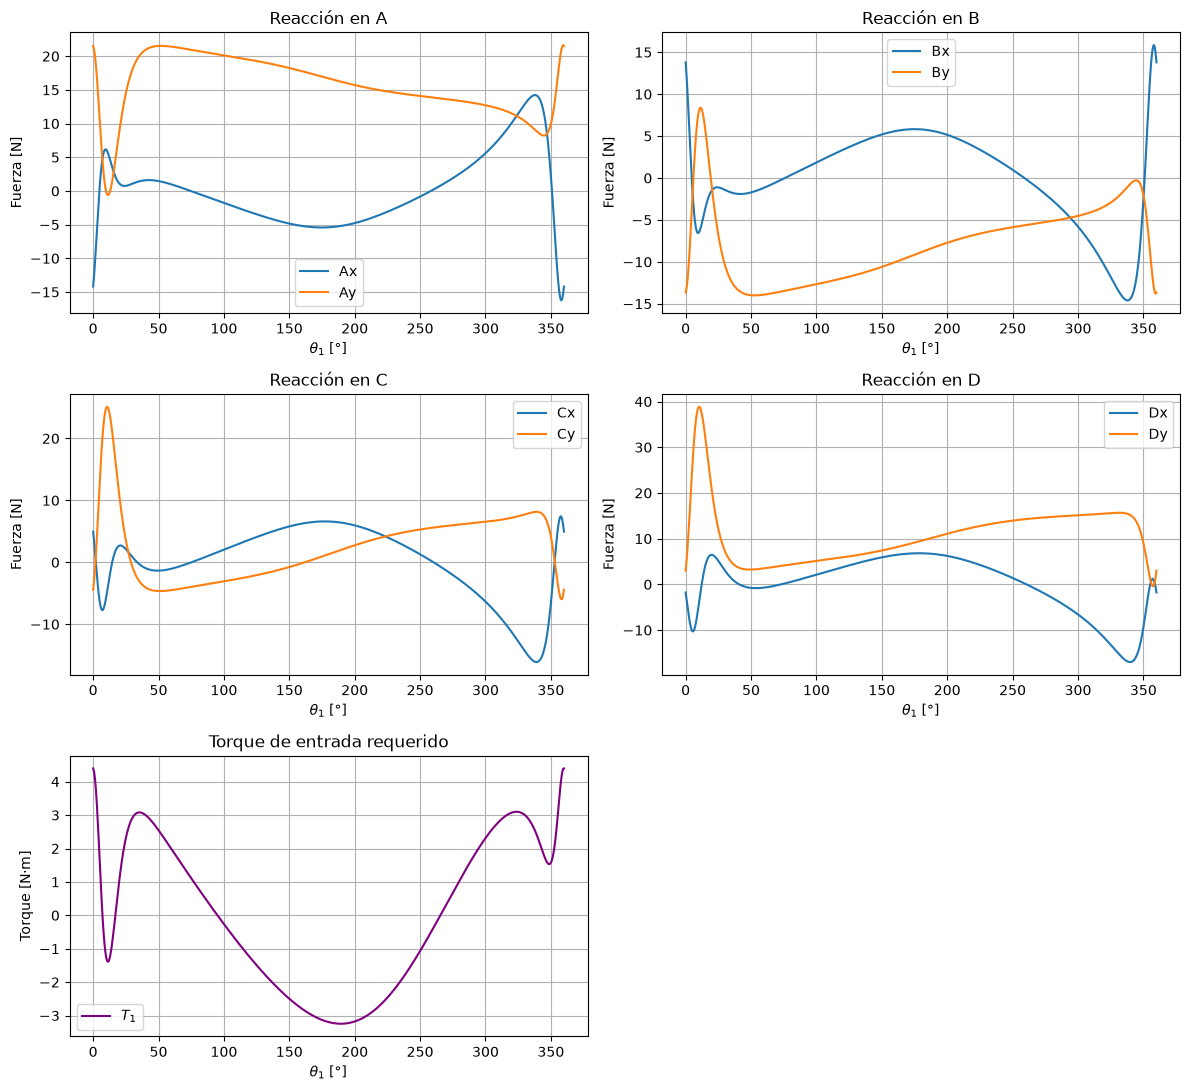

In [25]:
# Link masses [kg]
m1 = 0.80
m2 = 1.05
m3 = 0.85

# Mass moments of inertia about the center of mass [kg*m^2]
IG1 = 5.10e-3
IG2 = 1.24e-2
IG3 = 6.40e-3

# Gravitational acceleration [m/s^2]
g = 9.81

# Number of mechanism configurations
N = len(theta1_results)

# Initialize arrays for storing joint reaction forces
Ax_results = np.zeros(N)
Ay_results = np.zeros(N)

Bx_results = np.zeros(N)
By_results = np.zeros(N)

Cx_results = np.zeros(N)
Cy_results = np.zeros(N)

Dx_results = np.zeros(N)
Dy_results = np.zeros(N)

# Initialize array for storing the required input torque
T1_results = np.zeros(N)


# Perform force analysis for each mechanism configuration
for i in range(N):

    theta1 = theta1_results[i]
    theta2 = theta2_results[i]
    theta3 = theta3_results[i]

    alpha2 = alpha2_results[i]
    alpha3 = alpha3_results[i]

    aG1 = aG1_results[i]
    aG2 = aG2_results[i]
    aG3 = aG3_results[i]

    # ---------------------------------------------------------
    # Complete the dynamic force analysis here
    #
    # 1. Draw/consider the free-body diagram of each moving link.
    #
    # 2. Apply the Newton-Euler equations to Links 1, 2 and 3:
    #       Sum(Fx) = m*aGx
    #       Sum(Fy) = m*aGy
    #       Sum(MG) = IG*alpha
    #
    # 3. Combine the equations into a system of linear equations
    #    for the unknown joint reactions and input torque.
    #
    # 4. Solve the system for the current mechanism configuration.
    #
    # 5. Store the reaction forces and input torque in their
    #    corresponding result arrays.
    # ---------------------------------------------------------

    #Componentes de los vectores del centro de masa de cada enlace
    
    x1 = (L1 / 2) * np.cos(theta1)
    y1 = (L1 / 2) * np.sin(theta1)

    x2 = (L2 / 2) * np.cos(theta2)
    y2 = (L2 / 2) * np.sin(theta2)

    x3 = (L3 / 2) * np.cos(theta3)
    y3 = (L3 / 2) * np.sin(theta3)



    M = np.array([

        [ 1,   0,   1,   0,   0,   0,   0,   0,  0],
        [ 0,   1,   0,   1,   0,   0,   0,   0,  0],
        [y1, -x1, -y1,  x1,   0,   0,   0,   0,  1],


        [ 0,   0,  -1,   0,   1,   0,   0,   0,  0],
        [ 0,   0,   0,  -1,   0,   1,   0,   0,  0],
        [ 0,   0, -y2,  x2, -y2,  x2,   0,   0,  0],


        [ 0,   0,   0,   0,  -1,   0,   1,   0,  0],
        [ 0,   0,   0,   0,   0,  -1,   0,   1,  0],
        [ 0,   0,   0,   0,  y3, -x3,  y3, -x3,  0]
    ])


    rhs = np.array([
    m1 * aG1[0], m1 * aG1[1] + m1 * g, IG1 * alpha1, m2 * aG2[0], m2 * aG2[1] + m2 * g, IG2 * alpha2, m3 * aG3[0], m3 * aG3[1] + m3 * g, IG3 * alpha3
    ])

    (
        Ax_results[i], Ay_results[i],
        Bx_results[i], By_results[i],
        Cx_results[i], Cy_results[i],
        Dx_results[i], Dy_results[i],
        T1_results[i]
    ) = np.linalg.solve(M, rhs)


# -------------------------------------------------------------
# Plot the requested reaction forces and input torque
# as functions of theta1
# -------------------------------------------------------------

theta1_deg = np.rad2deg(theta1_results)

fig, axes = plt.subplots(3, 2, figsize=(12, 11))

joint_data = [
    ("A", Ax_results, Ay_results),
    ("B", Bx_results, By_results),
    ("C", Cx_results, Cy_results),
    ("D", Dx_results, Dy_results)
]

for ax, (joint, Fx, Fy) in zip(axes.flat, joint_data):
    ax.plot(theta1_deg, Fx, label=f"{joint}x")
    ax.plot(theta1_deg, Fy, label=f"{joint}y")
    ax.set_title(f"Reacción en {joint}")
    ax.set_xlabel(r"$\theta_1$ [°]")
    ax.set_ylabel("Fuerza [N]")
    ax.grid(True)
    ax.legend()

ax = axes[2, 0]
ax.plot(theta1_deg, T1_results, color="purple", label=r"$T_1$")
ax.set_title("Torque de entrada requerido")
ax.set_xlabel(r"$\theta_1$ [°]")
ax.set_ylabel("Torque [N·m]")
ax.grid(True)
ax.legend()

fig.delaxes(axes[2, 1])
fig.tight_layout()
plt.show()

# Stress Analysis

In the following cell, perform the stress analysis of **Link 2 (the coupler)** using the results obtained from the dynamic force analysis.

Consider a cross-section passing through the center of mass of Link 2, $G_2$. For each mechanism configuration, determine the internal reactions acting at this section and use them to calculate the corresponding stresses.

Let $N$ denote the number of mechanism configurations. In this case,

$$
N = 500.
$$

## Link 2 Cross-Section

Assume that Link 2 has a solid rectangular cross-section with the following dimensions:

- Width: $b = 18$ mm $= 0.018$ m
- Height: $h = 20$ mm $= 0.020$ m

Using these dimensions, calculate:

1. The cross-sectional area, $A$.
2. The second moment of area, $I$, about the neutral axis associated with in-plane bending.
3. The distance, $c$, from the neutral axis to the outermost fiber.

## Available Inputs

The following results from the previous analyses are available:

1. Angular position of Link 2:
   - *theta2_results* ($\theta_2$): shape $(N,)$

2. Joint forces acting on Link 2:
   - *Bx_results*: shape $(N,)$
   - *By_results*: shape $(N,)$
   - *Cx_results*: shape $(N,)$
   - *Cy_results*: shape $(N,)$

3. Acceleration of the center of mass of Link 2:
   - *aG2_results*: shape $(N,2)$

4. Mass of Link 2:
   - $m_2 = 1.05$ kg

## Internal Reactions

Make an imaginary cut through Link 2 at its center of mass, $G_2$, and isolate one half of the link.

For each mechanism configuration, determine the internal reactions acting at the cut:

1. Axial force, $U$
2. Shear force, $V$
3. Bending moment, $M$

The forces obtained from the dynamic force analysis are expressed in the global $x$-$y$ coordinate system. Transform the required force components into the local coordinate system of Link 2, where:

- The axial direction is parallel to Link 2.
- The transverse direction is perpendicular to Link 2.

Apply the appropriate dynamic equilibrium equations to the isolated portion of the link.

**Expected internal-reaction outputs:**

- *U_results*: shape $(N,)$
- *V_results*: shape $(N,)$
- *M_results*: shape $(N,)$

## Stress Analysis

Using the calculated internal reactions and cross-sectional properties, determine the following stresses for every mechanism configuration.

### Normal Stress

Calculate the normal stress resulting from the combined effects of axial force and bending moment.

At the two outermost fibers of the cross-section:

$$
\sigma_1 = \frac{U}{A} + \frac{Mc}{I}
$$

$$
\sigma_2 = \frac{U}{A} - \frac{Mc}{I}
$$

### Transverse Shear Stress

For the rectangular cross-section, calculate the maximum transverse shear stress:

$$
\tau_{\max} = \frac{3V}{2A}
$$

**Expected stress outputs:**

- *sigma_1_results*: shape $(N,)$
- *sigma_2_results*: shape $(N,)$
- *tau_max_results*: shape $(N,)$

## Plots

Plot the following quantities as functions of $\theta_1$:

1. The axial force $U$ and shear force $V$.
2. The bending moment $M$.
3. The normal stresses $\sigma_1$ and $\sigma_2$.
4. The maximum transverse shear stress $\tau_{\max}$.

Use $\theta_1$ in degrees for the horizontal axis.

Express:

- Forces in N.
- Moments in N·m.
- Stresses in MPa.

Include appropriate axis labels, legends, titles, and grid lines.

In [ ]:
# Cross-sectional dimensions of Link 2
b = 0.018       # Width [m]
h = 0.020       # Height [m]


# -------------------------------------------------------------
# Calculate the cross-sectional properties of Link 2:
#
#   A  : Cross-sectional area [m^2]
#   I  : Second moment of area [m^4]
#   c  : Distance from the neutral axis to the outermost fiber [m]
# -------------------------------------------------------------



# Number of mechanism configurations
N = len(theta1_results)


# -------------------------------------------------------------
# Initialize arrays for storing the internal reactions
# -------------------------------------------------------------

U_results = np.zeros(N)              # Normal force [N]
V_results = np.zeros(N)              # Shear force [N]
M_results = np.zeros(N)              # Bending moment [N*m]


# -------------------------------------------------------------
# Initialize arrays for storing the stresses
# -------------------------------------------------------------

sigma_1_results = np.zeros(N)        # Normal stress at one outermost fiber [Pa]
sigma_2_results = np.zeros(N)        # Normal stress at the opposite fiber [Pa]
tau_max_results = np.zeros(N)        # Maximum transverse shear stress [Pa]


# -------------------------------------------------------------
# Perform the stress analysis for each mechanism configuration
# -------------------------------------------------------------

for i in range(N):

    # Angular position of Link 2
    theta2 = theta2_results[i]

    # Joint forces acting on Link 2
    Bx = Bx_results[i]
    By = By_results[i]
    Cx = Cx_results[i]
    Cy = Cy_results[i]

    # Acceleration of the center of mass of Link 2
    aG2 = aG2_results[i]


    # ---------------------------------------------------------
    # Complete the stress analysis here
    #
    # 1. Make an imaginary cut through Link 2 at G2 and
    #    isolate one half of the link.
    #
    # 2. Determine the internal reactions at the cut:
    #
    #       U : Normal force
    #       V : Shear force
    #       M : Bending moment
    #
    #    The joint forces are expressed in the global x-y
    #    coordinate system. Transform the required forces into
    #    the local coordinate system of Link 2:
    #
    #       - Normal direction: parallel to Link 2
    #       - Transverse direction: perpendicular to Link 2
    #
    # 3. Apply the appropriate dynamic equilibrium equations
    #    to the isolated portion of the link.
    #
    # 4. Store U, V and M in their corresponding arrays.
    #
    # 5. Using A, I and c, calculate:
    #
    #       sigma_1 : Normal stress at one outermost fiber
    #       sigma_2 : Normal stress at the opposite fiber
    #       tau_max : Maximum transverse shear stress
    #
    # 6. Store the stress results in their corresponding arrays.
    # ---------------------------------------------------------



# -------------------------------------------------------------
# Plot the requested results as functions of theta1:
#
#   1. U and V
#   2. M
#   3. sigma_1 and sigma_2
#   4. tau_max
#
# Use theta1 in degrees.
# Express stresses in MPa.
# -------------------------------------------------------------